# 🧠 Étape 5 — Modèles Deep Learning : LSTM & GRU

On entraîne ici des réseaux de neurones récurrents sur les **séquences temporelles** produites à l'étape 2.

### Pourquoi LSTM/GRU ?
- Contrairement aux modèles ML (XGBoost, RF) qui voient les lags comme des colonnes indépendantes, les réseaux récurrents **traitent l'historique comme une séquence ordonnée** — ils apprennent les dépendances temporelles à long terme
- **LSTM** (Long Short-Term Memory) : gère les dépendances longues via une cellule mémoire et des portes (forget, input, output)
- **GRU** (Gated Recurrent Unit) : version simplifiée du LSTM, moins de paramètres, souvent aussi performant

### Plan
1. Chargement des séquences préprocessées
2. Construction des modèles LSTM et GRU avec PyTorch
3. Boucle d'entraînement avec early stopping
4. Évaluation et comparaison avec ML
5. Visualisation
6. Tableau final de tous les modèles
7. Sauvegarde

## 1. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# ── Paramètres globaux ────────────────────────────────────────────────────────

os.environ["CUDA_VISIBLE_DEVICES"] = ""  # masque le GPU, force CPU


HORIZON   = 600  # 10 minutes en secondes (donnees a 1Hz)
SAVE_DIR  = 'preprocessed'
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Utiliser le GPU si disponible, sinon CPU
DEVICE = torch.device('cpu')
print(f"Device : {DEVICE}")

# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/brice/Documents/Actemium/wadi_env/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/brice/Documents/Actemium/wadi_env/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/brice/Documents/Actemium/wadi_env/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in

Device : cpu


## 2. Chargement des données

On charge les **séquences 3D** produites à l'étape 2 : shape `(samples, timesteps=30, features)`.  
On charge aussi les références persistence pour le calcul du skill score.

In [2]:
X_seq_train = np.load(f'{SAVE_DIR}/X_seq_train.npy')  # (N_train, 30, n_features)
X_seq_test  = np.load(f'{SAVE_DIR}/X_seq_test.npy')
y_seq_train = np.load(f'{SAVE_DIR}/y_seq_train.npy')  # valeurs normalisées [0,1]
y_seq_test  = np.load(f'{SAVE_DIR}/y_seq_test.npy')

# Scaler pour inverser la normalisation de la cible
scaler_seq = joblib.load(f'{SAVE_DIR}/scaler_seq.pkl')

# Références
rmse_persistence = float(np.load(f'{SAVE_DIR}/rmse_persistence.npy')[0])
mae_persistence  = float(np.load(f'{SAVE_DIR}/mae_persistence.npy')[0])

# Timestamps du test pour les visualisations
ts_test = pd.read_csv(f'{SAVE_DIR}/ts_test.csv', parse_dates=[0]).iloc[:, 0]

print(f"X_seq_train : {X_seq_train.shape}")
print(f"X_seq_test  : {X_seq_test.shape}")
print(f"y_seq_train : {y_seq_train.shape}")
print(f"y_seq_test  : {y_seq_test.shape}")
print(f"\nTimesteps   : {X_seq_train.shape[1]}")
print(f"Features    : {X_seq_train.shape[2]}")
print(f"RMSE persistence (référence) : {rmse_persistence:.4f}")

X_seq_train : (5665, 30, 36)
X_seq_test  : (1388, 30, 36)
y_seq_train : (5665,)
y_seq_test  : (1388,)

Timesteps   : 30
Features    : 36
RMSE persistence (référence) : 0.0467


## 3. Dataset PyTorch

On encapsule les données dans une classe `Dataset` PyTorch pour pouvoir les charger en mini-batchs.  
Le `DataLoader` s'occupe du shuffling (uniquement sur le train) et du chargement par batchs.

In [3]:
class WadiDataset(Dataset):
    """Dataset PyTorch pour les séquences WADI."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 256

# Split train / validation (15% du train pour l'early stopping)
val_size  = int(len(X_seq_train) * 0.15)
X_tr      = X_seq_train[:-val_size]
X_val     = X_seq_train[-val_size:]
y_tr      = y_seq_train[:-val_size]
y_val     = y_seq_train[-val_size:]

train_loader = DataLoader(WadiDataset(X_tr, y_tr),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(WadiDataset(X_val, y_val),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(WadiDataset(X_seq_test, y_seq_test),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Train     : {len(X_tr):,} séquences")
print(f"Validation: {len(X_val):,} séquences")
print(f"Test      : {len(X_seq_test):,} séquences")
print(f"Batch size: {BATCH_SIZE}")

Train     : 4,816 séquences
Validation: 849 séquences
Test      : 1,388 séquences
Batch size: 256


## 4. Architecture des modèles

### LSTM
```
Input (batch, 30, n_features)
    → LSTM (2 couches, hidden=128, dropout=0.2)
    → Dernier timestep → Linear(128, 64) → ReLU
    → Linear(64, 1)
    → Output : niveau prédit à t+10
```

### GRU
Même architecture mais avec des cellules GRU — moins de paramètres, entraînement plus rapide.

**Choix de conception :**
- 2 couches récurrentes : capte des patterns temporels à différentes échelles
- Dropout entre les couches : régularisation pour éviter le surapprentissage
- On prend uniquement le **dernier état caché** (t=30) comme représentation de la séquence

In [4]:
class RecurrentModel(nn.Module):
    """
    Modèle LSTM ou GRU générique pour la prédiction de séries temporelles.
    Prend en entrée (batch, seq_len, n_features) et prédit un scalaire.
    """
    def __init__(self, model_type, input_size, hidden_size=128,
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.model_type = model_type

        rnn_cls = nn.LSTM if model_type == 'LSTM' else nn.GRU
        self.rnn = rnn_cls(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True   # entrée : (batch, seq, features)
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # out : (batch, seq_len, hidden_size)
        if self.model_type == 'LSTM':
            out, (h_n, _) = self.rnn(x)
        else:
            out, h_n = self.rnn(x)

        # On prend uniquement le dernier timestep
        last_hidden = out[:, -1, :]   # (batch, hidden_size)
        return self.head(last_hidden).squeeze(-1)  # (batch,)


INPUT_SIZE = X_seq_train.shape[2]

lstm_model = RecurrentModel('LSTM', INPUT_SIZE, hidden_size=128, num_layers=2).to(DEVICE)
gru_model  = RecurrentModel('GRU',  INPUT_SIZE, hidden_size=128, num_layers=2).to(DEVICE)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Paramètres LSTM : {count_params(lstm_model):,}")
print(f"Paramètres GRU  : {count_params(gru_model):,}")
print(f"\nArchitecture LSTM :")
print(lstm_model)

Paramètres LSTM : 225,409
Paramètres GRU  : 171,137

Architecture LSTM :
RecurrentModel(
  (rnn): LSTM(36, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 5. Boucle d'entraînement

On définit une fonction d'entraînement réutilisable pour LSTM et GRU.  

**Détails :**
- **Loss** : MSE (Mean Squared Error) — standard pour la régression
- **Optimiseur** : Adam avec learning rate scheduler (ReduceLROnPlateau — réduit le LR si la val loss stagne)
- **Early stopping** : arrêt si la val loss ne s'améliore pas pendant `patience` epochs, sauvegarde du meilleur modèle
- **Gradient clipping** : évite les gradients explosifs typiques des RNN

In [5]:
def train_model(model, train_loader, val_loader, model_name,
                lr=1e-3, max_epochs=100, patience=10):
    """
    Entraîne un modèle PyTorch avec early stopping et LR scheduling.
    Retourne l'historique des losses train/val.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False
    )
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    patience_counter = 0
    best_path = f'{MODEL_DIR}/{model_name}_best.pt'

    train_losses, val_losses = [], []

    for epoch in range(1, max_epochs + 1):
        # ── Phase entraînement ─────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
            optimizer.step()
            train_loss += loss.item() * len(X_batch)
        train_loss /= len(train_loader.dataset)

        # ── Phase validation ───────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                preds    = model(X_batch)
                val_loss += criterion(preds, y_batch).item() * len(X_batch)
        val_loss /= len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        # ── Early stopping ─────────────────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), best_path)
        else:
            patience_counter += 1

        if epoch % 10 == 0 or patience_counter == 0:
            lr_current = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:>3}/{max_epochs} | "
                  f"Train MSE: {train_loss:.6f} | "
                  f"Val MSE: {val_loss:.6f} | "
                  f"LR: {lr_current:.2e} | "
                  f"Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n⏹ Early stopping à l'epoch {epoch} (meilleure val loss: {best_val_loss:.6f})")
            break

    # Rechargement du meilleur modèle
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    print(f"\n✅ Meilleur modèle rechargé depuis '{best_path}'")
    return train_losses, val_losses

## 6. Fonction de prédiction et d'évaluation

On définit aussi une fonction commune pour récupérer les prédictions sur le jeu de test et calculer les métriques.  
Les prédictions sont en **valeurs normalisées** [0,1] — on les repasse en valeurs réelles via le scaler.

In [6]:
def predict(model, loader):
    model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            pred = model(X_batch)
            preds_all.extend(pred.tolist())
            true_all.extend(y_batch.tolist())
    return np.array(preds_all), np.array(true_all)

all_results_dl = []

def evaluate_dl(y_true_norm, y_pred_norm, label, scaler):
    """
    Inverse la normalisation puis calcule MAE, RMSE, Skill.
    Les valeurs normalisées correspondent à la colonne TARGET (index 0) du scaler_seq.
    """
    # Inverse transform : on reconstruit un tableau avec la même structure que le scaler
    n_features = scaler.n_features_in_

    def inverse_target(arr_norm):
        dummy = np.zeros((len(arr_norm), n_features))
        dummy[:, 0] = arr_norm   # TARGET est la colonne 0
        return scaler.inverse_transform(dummy)[:, 0]

    y_true = inverse_target(y_true_norm)
    y_pred = inverse_target(y_pred_norm)

    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    skill = (1 - rmse / rmse_persistence) * 100
    impr_mae = (1 - mae / mae_persistence) * 100

    print(f"{'─'*45}")
    print(f" {label}")
    print(f"{'─'*45}")
    print(f"  MAE   : {mae:.4f}   (vs persistence : {impr_mae:+.1f}%)")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  Skill : {skill:+.2f}%")
    objectif = "✅ Objectif atteint" if skill >= 20 else "❌ Objectif non atteint (<20%)"
    print(f"  {objectif}")
    print()

    all_results_dl.append({'Modèle': label, 'MAE': round(mae, 4),
                           'RMSE': round(rmse, 4), 'Skill (%)': round(skill, 2)})
    return y_true, y_pred

## 7. Entraînement LSTM

**Résultat attendu :** val loss qui converge, early stopping entre l'epoch 30 et 80, skill score > 20%.

In [7]:
print("=" * 50)
print(" ENTRAÎNEMENT LSTM")
print("=" * 50)

lstm_train_losses, lstm_val_losses = train_model(
    lstm_model, train_loader, val_loader,
    model_name='lstm',
    lr=1e-3,
    max_epochs=100,
    patience=12
)

 ENTRAÎNEMENT LSTM
Epoch   1/100 | Train MSE: 0.087695 | Val MSE: 0.214477 | LR: 1.00e-03 | Patience: 0/12
Epoch   2/100 | Train MSE: 0.048745 | Val MSE: 0.199032 | LR: 1.00e-03 | Patience: 0/12
Epoch   3/100 | Train MSE: 0.027832 | Val MSE: 0.012389 | LR: 1.00e-03 | Patience: 0/12
Epoch  10/100 | Train MSE: 0.002871 | Val MSE: 0.017515 | LR: 5.00e-04 | Patience: 7/12

⏹ Early stopping à l'epoch 15 (meilleure val loss: 0.012389)

✅ Meilleur modèle rechargé depuis 'models/lstm_best.pt'


In [8]:
y_pred_lstm_norm, y_true_lstm_norm = predict(lstm_model, test_loader)
y_true_lstm, y_pred_lstm = evaluate_dl(
    y_true_lstm_norm, y_pred_lstm_norm, 'LSTM', scaler_seq
)

─────────────────────────────────────────────
 LSTM
─────────────────────────────────────────────
  MAE   : 0.6639   (vs persistence : -1855.5%)
  RMSE  : 0.7806
  Skill : -1572.72%
  ❌ Objectif non atteint (<20%)



## 8. Entraînement GRU

**Résultat attendu :** performances similaires ou légèrement inférieures au LSTM, mais entraînement plus rapide.

In [9]:
print("=" * 50)
print(" ENTRAÎNEMENT GRU")
print("=" * 50)

gru_train_losses, gru_val_losses = train_model(
    gru_model, train_loader, val_loader,
    model_name='gru',
    lr=1e-3,
    max_epochs=100,
    patience=12
)

 ENTRAÎNEMENT GRU
Epoch   1/100 | Train MSE: 0.075389 | Val MSE: 0.191871 | LR: 1.00e-03 | Patience: 0/12
Epoch   2/100 | Train MSE: 0.044149 | Val MSE: 0.144984 | LR: 1.00e-03 | Patience: 0/12
Epoch   3/100 | Train MSE: 0.017858 | Val MSE: 0.006290 | LR: 1.00e-03 | Patience: 0/12
Epoch   4/100 | Train MSE: 0.005041 | Val MSE: 0.002919 | LR: 1.00e-03 | Patience: 0/12
Epoch   9/100 | Train MSE: 0.003009 | Val MSE: 0.001451 | LR: 1.00e-03 | Patience: 0/12
Epoch  10/100 | Train MSE: 0.003224 | Val MSE: 0.001404 | LR: 1.00e-03 | Patience: 0/12
Epoch  20/100 | Train MSE: 0.002536 | Val MSE: 0.003698 | LR: 5.00e-04 | Patience: 10/12

⏹ Early stopping à l'epoch 22 (meilleure val loss: 0.001404)

✅ Meilleur modèle rechargé depuis 'models/gru_best.pt'


In [10]:
y_pred_gru_norm, y_true_gru_norm = predict(gru_model, test_loader)
y_true_gru, y_pred_gru = evaluate_dl(
    y_true_gru_norm, y_pred_gru_norm, 'GRU', scaler_seq
)

─────────────────────────────────────────────
 GRU
─────────────────────────────────────────────
  MAE   : 0.1690   (vs persistence : -397.7%)
  RMSE  : 0.2015
  Skill : -331.76%
  ❌ Objectif non atteint (<20%)



## 9. Courbes d'apprentissage

On compare les courbes train/val de LSTM et GRU.  
Une bonne courbe : train et val convergent ensemble, sans écart croissant (surapprentissage).

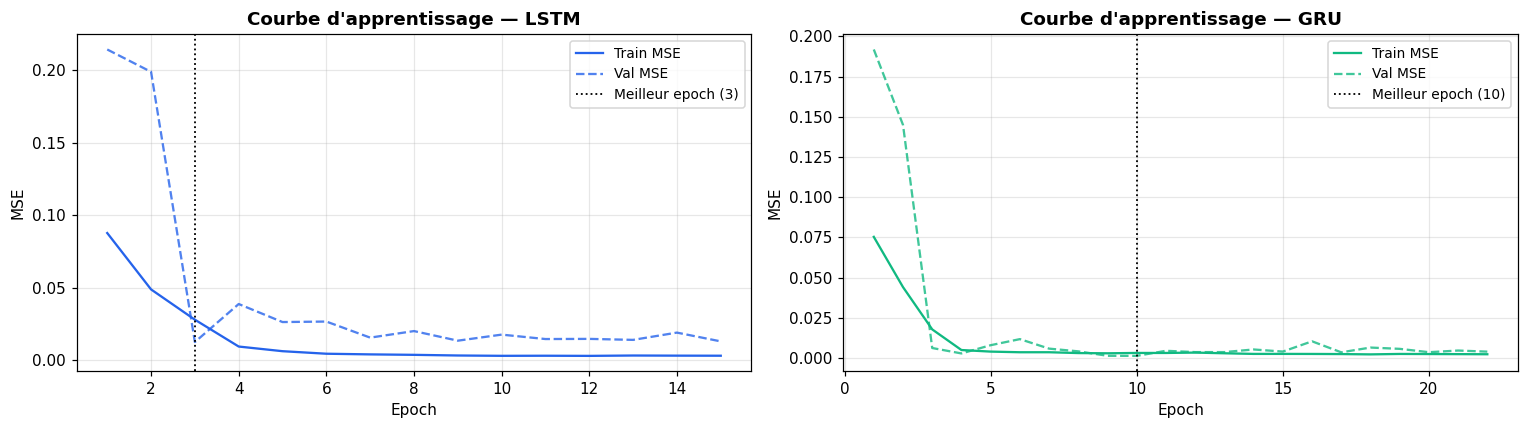

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, train_l, val_l, title, color in zip(
    axes,
    [lstm_train_losses, gru_train_losses],
    [lstm_val_losses,   gru_val_losses],
    ['LSTM', 'GRU'],
    ['#2563EB', '#10B981']
):
    epochs = range(1, len(train_l) + 1)
    ax.plot(epochs, train_l, color=color,     linewidth=1.5, label='Train MSE')
    ax.plot(epochs, val_l,   color=color,     linewidth=1.5, label='Val MSE',
            linestyle='--', alpha=0.8)
    best_ep = int(np.argmin(val_l)) + 1
    ax.axvline(best_ep, color='black', linestyle=':', linewidth=1.2,
               label=f'Meilleur epoch ({best_ep})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.set_title(f'Courbe d\'apprentissage — {title}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Visualisation des prédictions

On compare LSTM, GRU et persistence sur un extrait du test.  
On zoome également sur une **période de changement brusque** pour voir si les modèles DL anticipent mieux que la persistence.

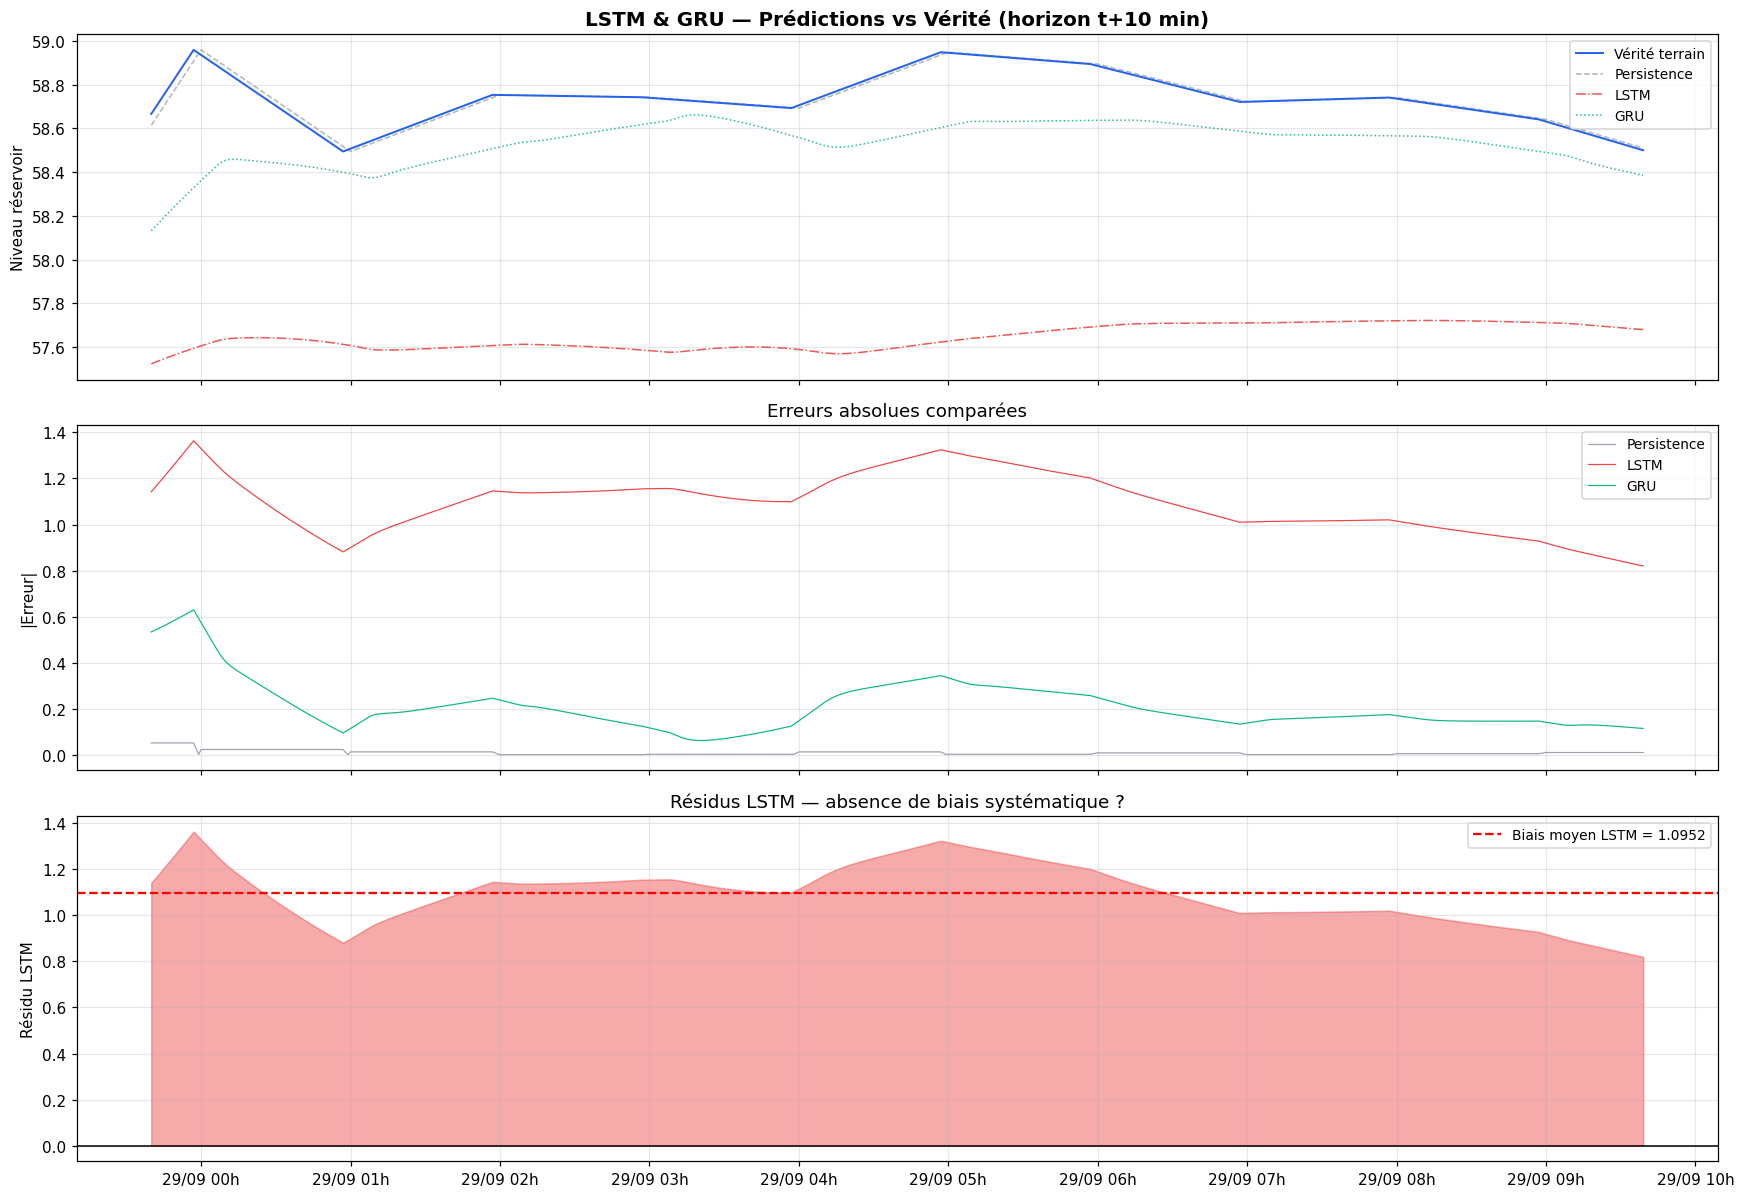

In [12]:
# Rechargement des donnees avec la methode corrigee (Row = 1 seconde)
df_raw = pd.read_csv("WADI_14days_new.csv")
START_TIME = pd.Timestamp("2017-09-25 00:00:00")
df_raw["datetime"] = START_TIME + pd.to_timedelta(df_raw["Row"] - 1, unit="s")
df_raw = df_raw.drop(columns=["Row", "Date", "Time"], errors="ignore")
for col in df_raw.columns:
    if col != "datetime":
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")
df_raw = df_raw.set_index("datetime").sort_index()

# Aligner les timestamps du test avec les sequences (window_size points en moins au debut)
WINDOW_SIZE = X_seq_test.shape[1]  # = 30
ts_seq = ts_test.iloc[WINDOW_SIZE:].reset_index(drop=True)
n_seq  = min(len(ts_seq), len(y_true_lstm))
ts_seq = ts_seq.iloc[:n_seq]

y_pers = df_raw["1_LT_001_PV"].reindex(ts_seq).values
y_tru  = y_true_lstm[:n_seq]
y_lstm = y_pred_lstm[:n_seq]
y_gru  = y_pred_gru[:n_seq]


## 11. Scatter plots

Visualisation prédit vs réel pour LSTM et GRU — les points doivent être alignés sur la diagonale y=x.

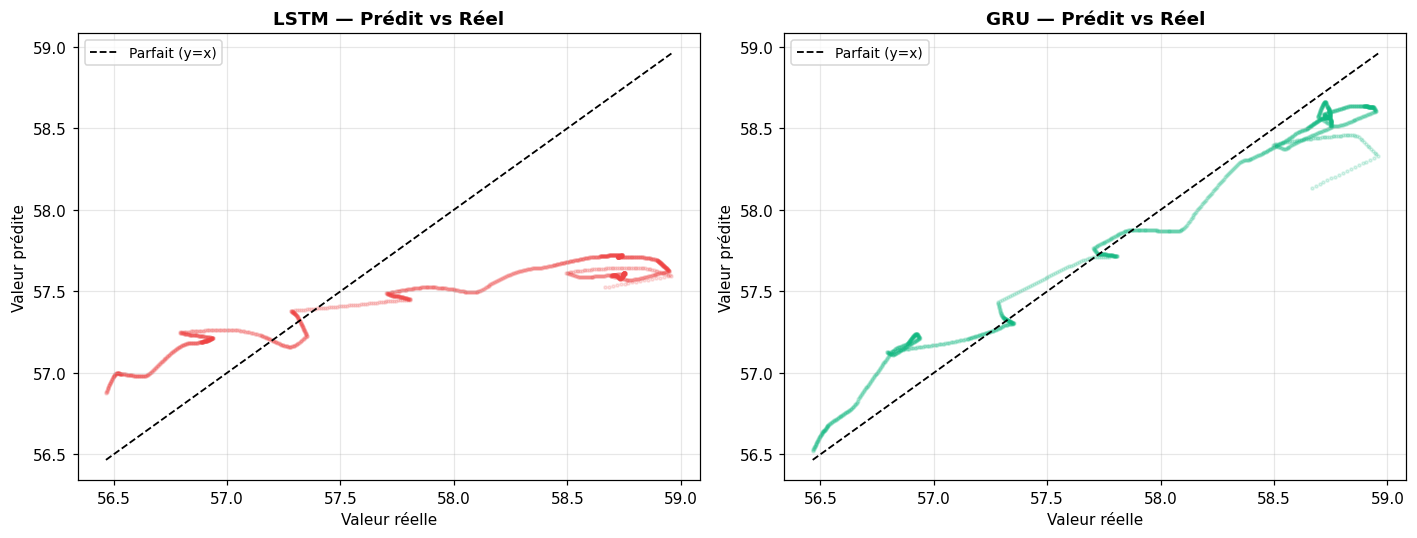

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title, color in zip(
    axes,
    [y_lstm, y_gru],
    ['LSTM', 'GRU'],
    ['#EF4444', '#10B981']
):
    n = min(5000, len(y_tru))
    ax.scatter(y_tru[:n], y_pred[:n], alpha=0.15, s=4, color=color)
    lims = [min(y_tru.min(), y_pred.min()), max(y_tru.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Parfait (y=x)')
    ax.set_xlabel('Valeur réelle')
    ax.set_ylabel('Valeur prédite')
    ax.set_title(f'{title} — Prédit vs Réel', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Tableau final — Tous les modèles

On compile ici **tous les résultats** : baselines + ML + DL dans un seul tableau pour choisir le meilleur modèle.

 TABLEAU FINAL — TOUS LES MODÈLES
                  Modèle    MAE   RMSE  Skill (%)
                     GRU 0.1690 0.2015  -331.7600
  Random Forest (défaut) 0.3404 0.4366  -835.4800
Random Forest (optimisé) 0.3424 0.4389  -840.5100
      XGBoost (optimisé) 0.3768 0.4726  -912.6500
                    LSTM 0.6639 0.7806 -1572.7200
        XGBoost (défaut) 0.7575 0.9585 -1953.9900
XGBoost (final optimisé) 0.7611 0.9656 -1969.2000
   Moyenne train (naive) 2.5341 2.6669 -5614.8227
  Persistence (t → t+10) 0.0339 0.0467        NaN


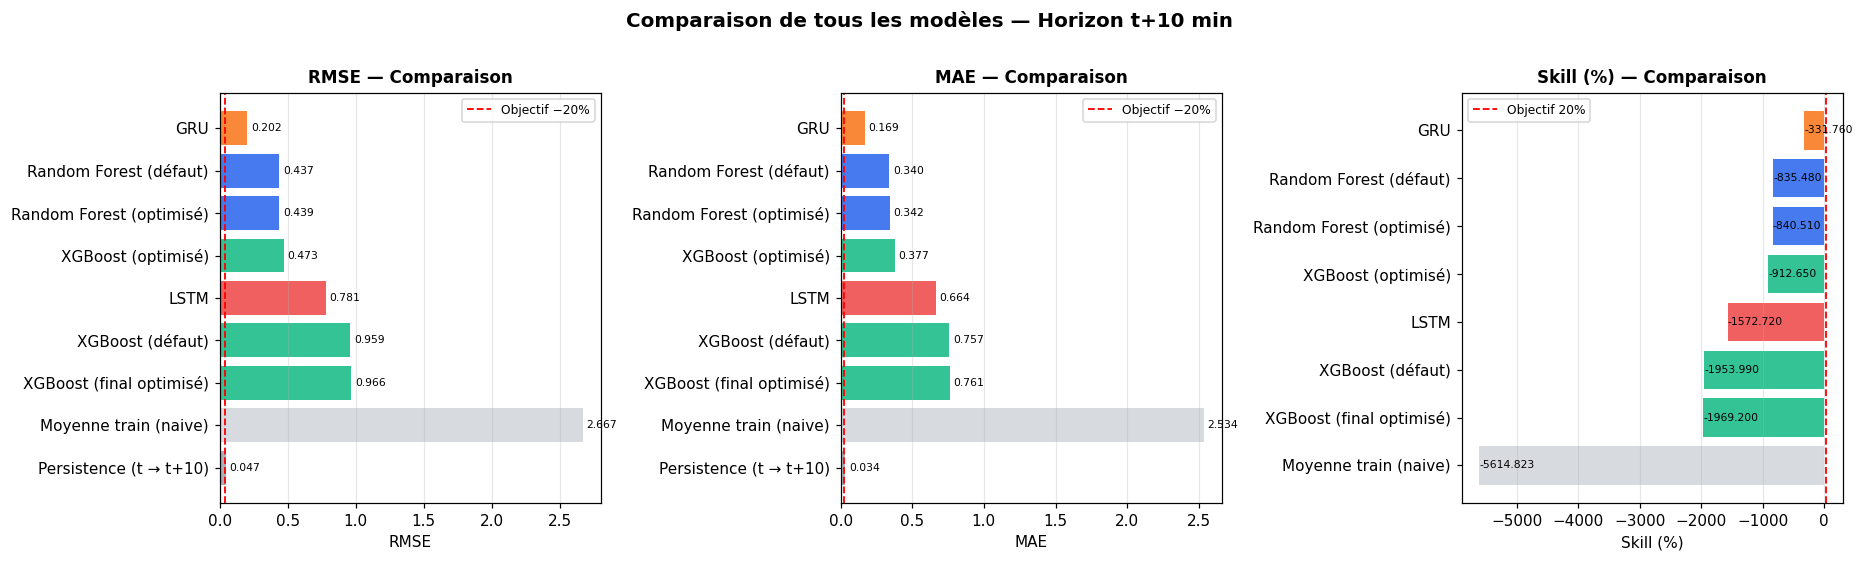

In [14]:
# Chargement des résultats précédents (baseline + ML)
try:
    df_prev = pd.read_csv(f'{SAVE_DIR}/resultats_tous_modeles.csv')
except FileNotFoundError:
    df_prev = pd.read_csv(f'{SAVE_DIR}/resultats_baselines.csv')

df_dl    = pd.DataFrame(all_results_dl)
df_final = pd.concat([df_prev, df_dl], ignore_index=True).drop_duplicates(subset='Modèle')
df_final = df_final.sort_values('Skill (%)', ascending=False).reset_index(drop=True)

print("=" * 60)
print(" TABLEAU FINAL — TOUS LES MODÈLES")
print("=" * 60)
print(df_final.to_string(index=False))
print("=" * 60)

# ── Graphique comparatif ──────────────────────────────────────────────────────
color_map = {
    'Persistence': '#9CA3AF', 'Moyenne': '#D1D5DB',
    'Random Forest': '#2563EB', 'XGBoost': '#10B981',
    'LSTM': '#EF4444', 'GRU': '#F97316',
}
def get_color(name):
    for k, v in color_map.items():
        if k in name: return v
    return '#6B7280'

colors = [get_color(m) for m in df_final['Modèle']]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'Skill (%)']):
    bars = ax.barh(df_final['Modèle'][::-1], df_final[metric][::-1],
                   color=colors[::-1], alpha=0.85)
    if metric == 'RMSE':
        ax.axvline(rmse_persistence * 0.8, color='red', linestyle='--',
                   linewidth=1.2, label='Objectif −20%')
        ax.legend(fontsize=8)
    elif metric == 'MAE':
        ax.axvline(mae_persistence * 0.8, color='red', linestyle='--',
                   linewidth=1.2, label='Objectif −20%')
        ax.legend(fontsize=8)
    elif metric == 'Skill (%)':
        ax.axvline(20, color='red', linestyle='--',
                   linewidth=1.2, label='Objectif 20%')
        ax.legend(fontsize=8)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} — Comparaison', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + ax.get_xlim()[1]*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{w:.3f}', va='center', fontsize=7)

plt.suptitle(f'Comparaison de tous les modèles — Horizon t+{HORIZON} min',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 13. Sauvegarde

On sauvegarde les modèles PyTorch, les prédictions et le tableau final.

In [15]:
# Modèles PyTorch (déjà sauvegardés par l'early stopping, on sauvegarde aussi les configs)
torch.save({
    'model_type': 'LSTM',
    'input_size': INPUT_SIZE,
    'hidden_size': 128,
    'num_layers': 2,
    'state_dict': lstm_model.state_dict()
}, f'{MODEL_DIR}/lstm_final.pt')

torch.save({
    'model_type': 'GRU',
    'input_size': INPUT_SIZE,
    'hidden_size': 128,
    'num_layers': 2,
    'state_dict': gru_model.state_dict()
}, f'{MODEL_DIR}/gru_final.pt')

# Prédictions (valeurs réelles dénormalisées)
np.save(f'{SAVE_DIR}/y_pred_lstm.npy', y_pred_lstm)
np.save(f'{SAVE_DIR}/y_pred_gru.npy',  y_pred_gru)
np.save(f'{SAVE_DIR}/y_true_dl.npy',   y_true_lstm)  # référence commune

# Tableau final complet
df_final.to_csv(f'{SAVE_DIR}/resultats_final.csv', index=False)

print("✅ Sauvegarde terminée")
print(f"  {MODEL_DIR}/lstm_final.pt")
print(f"  {MODEL_DIR}/gru_final.pt")
print(f"  {SAVE_DIR}/y_pred_lstm.npy")
print(f"  {SAVE_DIR}/y_pred_gru.npy")
print(f"  {SAVE_DIR}/resultats_final.csv")
print()

best_model = df_final.iloc[0]
print(f"🏆 Meilleur modèle : {best_model['Modèle']}")
print(f"   MAE   = {best_model['MAE']:.4f}")
print(f"   RMSE  = {best_model['RMSE']:.4f}")
print(f"   Skill = {best_model['Skill (%)']:.2f}%")
print()
print("→ Prochaine étape : analyse_shap.ipynb (feature importance SHAP)")

✅ Sauvegarde terminée
  models/lstm_final.pt
  models/gru_final.pt
  preprocessed/y_pred_lstm.npy
  preprocessed/y_pred_gru.npy
  preprocessed/resultats_final.csv

🏆 Meilleur modèle : GRU
   MAE   = 0.1690
   RMSE  = 0.2015
   Skill = -331.76%

→ Prochaine étape : analyse_shap.ipynb (feature importance SHAP)
